Contenido bajo licencia Creative Commons BY 4.0 y código bajo licencia MIT. © Nicolás Guarín-Zapata 2026.

# Método de diferencias finitas en 1D

Como dijimos en clase, la ecuación diferencial elíptica _por excelencia_
es la ecuación de Poisson:

$$\nabla^2 u(\mathbf{x}) + f(\mathbf{x}) = 0\quad \forall \mathbf{x} \in \Omega\, ,$$

con $\Omega \subset \mathbb{R}^n$ ($n=1, 2, 3$).

## Solución por diferencias finitas en 1D

Para ilustrar la solución de EDP elípticas, planteemos el esquema para el problema

$$\frac{d^2 u(x)}{dx^2} + f(x) = 0\quad \forall x \in (0, 1)\, ,$$

con $u(0) = u_a$ y $u(1) = u_b$. Que tiene como solución analítica

$$u(x) = - \int\left[\int f(x) \mathrm{d}x\right] \mathrm{d}x + C_1 x + C_2\, ,$$

donde $C_1$ y $C_2$ se encuentran evaluando las condiciones de frontera.

### Solución numérica

Para la solución numérica pensemos que queremos evaluar la función en
la rejilla con $m + 2$ puntos y valores $U_0, U_1, \cdots, U_m, U_{m + 1}$.
Tenemos que $x_j = jh$, $\Delta x = 1/(m + 1)$,  $U_0 =u_a$ y $U_{m + 1} = u_b$.

Para este problema, tenemos $m$ incógnitas ($U_1, U_2, \cdots, U_m$) por calcular.
Para formar el sistema de ecuaciones usemos la diferencia central alrededor
del punto $U_j$

$$D^2 U_j = \frac{1}{\Delta x^2}[U_{j - 1} - 2U_j + U_{j + 1}]\, ,$$

y para puntos interiores se cumple que

$$\frac{1}{\Delta x^2}[U_{j - 1} - 2U_j + U_{j + 1}] = -f_j\, ,\quad j=1, \cdots, m\, ,$$

con $f_j = f(x_j)$.

Las ecuaciones $i-1$, $i$ e $i + 1$ son

\begin{align}
\frac{1}{\Delta x^2}[U_{i - 2} - 2U_{i - 1} + U_{i}] &= -f_{i - 1} \, ,\\
\frac{1}{\Delta x^2}[U_{i - 1} - 2U_{i} + U_{i + 1}] &= -f_{i} \, ,\\
\frac{1}{\Delta x^2}[U_{i} - 2U_{i + 1} + U_{i + }] &= -f_{i + 1} \, ,
\end{align}

lo que nos muestra la forma de la matriz general para los puntos internos.

Podemos escribir el problema como

$$A U = b\, ,$$

con $U = (U_0, U_1, \cdots, U_{m + 1})$.

Los elementos diferentes de cero en la matriz son los siguientes

\begin{align}
A_{i, i- 1} &= A_{i, i + 1} = \frac{1}{\Delta x^2}\, , \\
A_{i, i} &= -\frac{2}{\Delta x^2}\, ,
\end{align}

para $i = 1, 2, \cdots, m$.

La primera y última ecuaciones son las condiciones de frontera, luego

\begin{align}
A_{0, 0} &= A_{m + 1, m + 1} = 1\, ,\\
A_{0, 1} &= A_{m + 1, m} = 0\, .
\end{align}

El lado derecho del sistema de ecuaciones es $b = (b_0, b_1, \cdots, b_{m + 1})$, con

\begin{align}
b_0 &= u_a\, ,\\
b_i &= -f_i\, , \quad i=1, \cdots, m\\
b_{m + 1} &= u_b\, .
\end{align}

Veamos una implementación en Python de este algoritmo.

### Ejemplo

Probemos la implementación con la función $f(x) = 20 x^3$, que lleva a
la solución

$$u(x) = - x (x^4 - 1)$$



In [1]:
if 'google.colab' in str(get_ipython()):
    %pip install ipympl
    from google.colab import output
    output.enable_custom_widget_manager()

In [2]:
%matplotlib widget

Para armar el sistema de ecuaciones haremos uso
de la función ``diags`` de NumPy. Este permite crear una matriz a partir de sus diagonales.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import diag
from scipy.linalg import solve

In [4]:
repo = "https://raw.githubusercontent.com/nicoguaro/matplotlib_styles/master"
style = repo + "/styles/clean.mplstyle"
plt.style.use(style)

In [5]:
m = 50
x = np.linspace(0, 1, m + 2)
dx = x[1] - x[0]

In [6]:
diag0 = [-2/dx**2] * (m + 2)
diag0[0] = 1
diag0[-1] = 1
diag1 = [1/dx**2] * (m + 1)
diag1[0] = 0

A = diag(diag0) + diag(diag1, k=1) + diag(diag1[::-1], k=-1)
b = -20*x**3
b[0] = 0
b[-1] = 0

In [7]:
sol = solve(A, b)

In [8]:
sol_ex = -x*(x**4 - 1)

Text(0, 0.5, '$u(x)$')

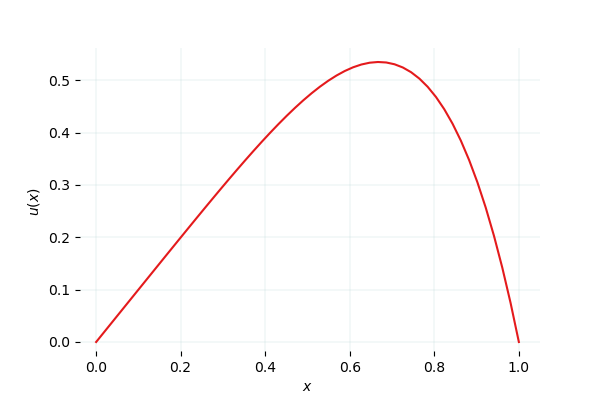

In [9]:
plt.figure()
plt.plot(x, sol)
plt.xlabel("$x$")
plt.ylabel("$u(x)$")

Text(0, 0.5, 'Error relativo')

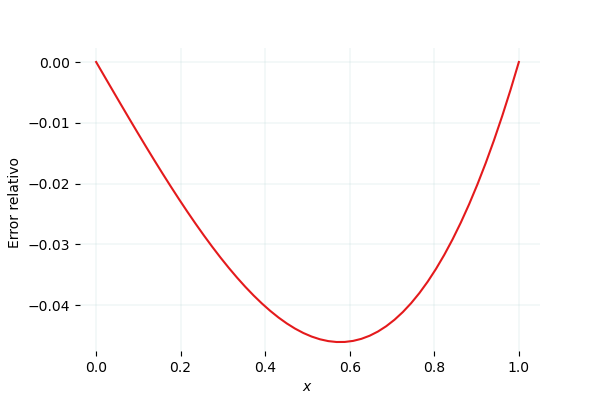

In [10]:
plt.figure()
plt.plot(x, 100*(sol - sol_ex)/np.max(sol_ex))
plt.xlabel("$x$")
plt.ylabel("Error relativo")